In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
data = {
    'Customer_ID': range(1, 16),

    'Annual_Income': [
        15, 16, 17, 18, 20,
        40, 42, 45, 47, 50,
        70, 72, 75, 78, 80
    ],

    'Spending_Score': [
        85, 80, 90, 88, 82,
        60, 65, 55, 62, 58,
        20, 25, 18, 22, 15
    ]
}

df = pd.DataFrame(data)

print(df)

    Customer_ID  Annual_Income  Spending_Score
0             1             15              85
1             2             16              80
2             3             17              90
3             4             18              88
4             5             20              82
5             6             40              60
6             7             42              65
7             8             45              55
8             9             47              62
9            10             50              58
10           11             70              20
11           12             72              25
12           13             75              18
13           14             78              22
14           15             80              15


In [4]:
print(df.head())

   Customer_ID  Annual_Income  Spending_Score
0            1             15              85
1            2             16              80
2            3             17              90
3            4             18              88
4            5             20              82


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer_ID     15 non-null     int64
 1   Annual_Income   15 non-null     int64
 2   Spending_Score  15 non-null     int64
dtypes: int64(3)
memory usage: 492.0 bytes
None


In [6]:
print(df.isnull().sum())

Customer_ID       0
Annual_Income     0
Spending_Score    0
dtype: int64


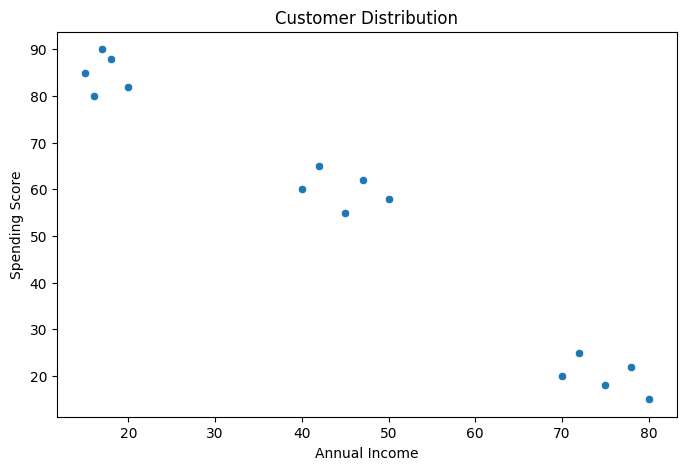

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score'
)

plt.title('Customer Distribution')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

In [8]:
X = df[
    [
        'Annual_Income',
        'Spending_Score'
    ]
]

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
inertia = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

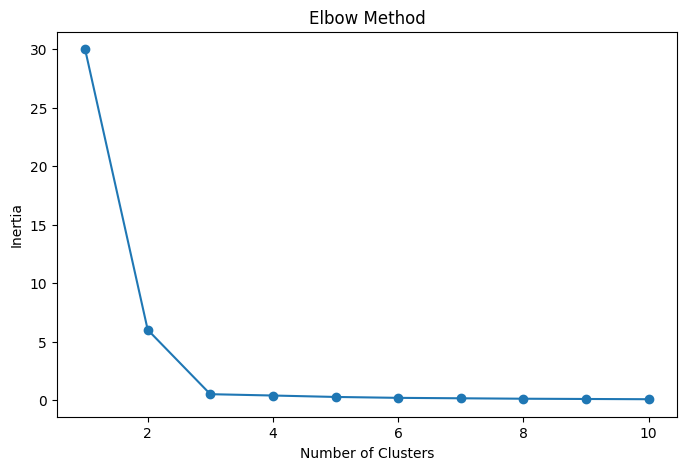

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.show()

In [12]:
k = 3

In [13]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
print(df)

    Customer_ID  Annual_Income  Spending_Score  Cluster
0             1             15              85        2
1             2             16              80        2
2             3             17              90        2
3             4             18              88        2
4             5             20              82        2
5             6             40              60        0
6             7             42              65        0
7             8             45              55        0
8             9             47              62        0
9            10             50              58        0
10           11             70              20        1
11           12             72              25        1
12           13             75              18        1
13           14             78              22        1
14           15             80              15        1


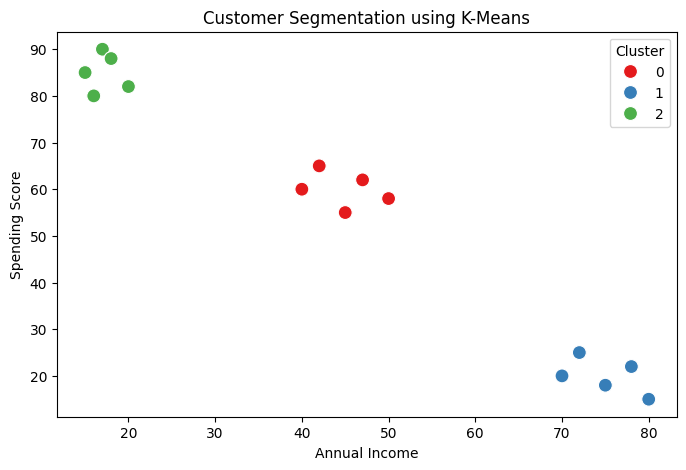

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation using K-Means')

plt.xlabel('Annual Income')

plt.ylabel('Spending Score')

plt.show()

In [16]:
cluster_summary = df.groupby(
    'Cluster'
)[
    [
        'Annual_Income',
        'Spending_Score'
    ]
].mean()

print(cluster_summary)

         Annual_Income  Spending_Score
Cluster                               
0                 44.8            60.0
1                 75.0            20.0
2                 17.2            85.0
